In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
# load processed df
from IPython.utils.capture import capture_output

with capture_output():
    %run balance_over_time.ipynb

In [3]:
import time
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [4]:
features_df

,balance__mean__all,balance__median__all,balance__min__all,balance__max__all,balance__std__all,balance__pct_negative__all,balance__pct_below_100__all,balance__pct_below_500__all,n_days__all,balance__mean__30d,...,cat_39__cat_n__90d,cat_40__cat_n__90d,cat_45__cat_n__90d,cat_46__cat_n__90d,income__total__all,essentials_spend__total__all,discretionary_spend__total__all,essentials__pct_of_income__all,discretionary__pct_of_income__all,DQ_TARGET
prism_consumer_id,,,,,,,,,,,,,,,,,,,,,
0,276.961538,70.09,-1019.10,2732.86,1016.288836,0.475524,0.510490,0.580420,143.0,-497.176071,...,3.0,1.0,0.0,0.0,9340.520508,1718.160034,7332.270020,0.183947,0.784996,0.0
1,1674.533585,1758.35,-123.25,3597.09,1159.524803,0.056604,0.094340,0.301887,106.0,2671.932727,...,0.0,2.0,0.0,0.0,13414.009766,680.210022,11539.479492,0.050709,0.860256,0.0
10,-106.435115,-98.40,-1108.49,929.25,501.726601,0.595420,0.633588,0.839695,131.0,-382.525455,...,0.0,1.0,0.0,4.0,15513.070312,1527.850220,9379.980469,0.098488,0.604650,0.0
100,-3231.228909,-3752.93,-6273.18,802.40,2080.213280,0.963636,0.963636,0.981818,55.0,-4166.195000,...,0.0,0.0,0.0,0.0,24423.531250,18534.431641,200.000000,0.758876,0.008189,0.0
1000,1013.427875,615.39,-22.85,12589.57,1545.044777,0.025000,0.112500,0.437500,80.0,601.327692,...,0.0,0.0,1.0,0.0,58994.343750,17348.220703,0.000000,0.294066,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,49.549474,-44.27,-121.55,776.47,238.842211,0.631579,0.754386,0.929825,57.0,-15.570000,...,2.0,0.0,0.0,0.0,11226.839844,6032.720703,2211.799805,0.537348,0.197010,NaN
9996,172.754000,184.21,32.72,297.21,76.111644,0.000000,0.200000,1.000000,30.0,179.411000,...,0.0,0.0,0.0,0.0,0.030000,331.070038,365.749969,11035.667969,12191.665039,NaN
9997,993.787302,863.25,96.23,2334.40,558.853248,0.000000,0.015873,0.174603,63.0,939.261304,...,6.0,0.0,0.0,0.0,17007.861328,7687.240234,2637.039795,0.451982,0.155048,NaN


In [5]:
'DQ_TARGET' in features_df.columns

True

# Data Preparation

In [6]:
# keep only labeled rows
df = features_df[features_df["DQ_TARGET"].notna()].copy()

X = df.drop(columns=["DQ_TARGET"])
y = df["DQ_TARGET"].astype(int)

## Train Test Split

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Prepare Data
# ---------------------------------------------------------
# Ensure no infinite values
df = features_df.replace([np.inf, -np.inf], np.nan)
df = df[df["DQ_TARGET"].notna()].copy()

X = df.drop(columns=["DQ_TARGET"]).select_dtypes(include=[np.number]).fillna(0)
y = df["DQ_TARGET"].astype(int)

# 2. Create Train / Validation / Test Split (60% / 20% / 20%)
# ---------------------------------------------------------
# First Split: Separate out the Test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Second Split: Separate the remaining 80% into Train (60%) and Val (20%)
# (0.25 of the remaining 80% = 20% of the total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Data Shapes:")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Data Shapes:
Train: (6189, 177) | Val: (2064, 177) | Test: (2064, 177)


# Mutual Information Feature Selection

In [8]:
k_mi = 75

mi_vals = mutual_info_classif(
    X_train.values,
    y_train.values,
    n_neighbors=3,
    random_state=42
)

mi_scores = pd.Series(mi_vals, index=X_train.columns).sort_values(ascending=False)
selected_mi = mi_scores.head(k_mi).index.tolist()

X_train_mi = X_train[selected_mi]
X_val_mi   = X_val[selected_mi]
X_test_mi  = X_test[selected_mi]

print(f"Selected top-{k_mi} MI features")
selected_mi[:15]

Selected top-75 MI features


['balance__mean__30d',
 'balance__median__all',
 'balance__mean__90d',
 'balance__min__90d',
 'n_days__180d',
 'balance__mean__all',
 'balance__mean__60d',
 'balance__mean__180d',
 'balance__min__30d',
 'balance__min__60d',
 'balance__std__all',
 'cat_23__cat_net_total__90d',
 'balance__min__180d',
 'n_days__all',
 'balance__max__all']

In [9]:
def evaluate_model(model, name, Xtr, ytr, Xva, yva, Xte, yte):
    start = time.time()
    model.fit(Xtr, ytr)
    fit_time = time.time() - start

    start = time.time()
    val_probs = model.predict_proba(Xva)[:, 1]
    test_probs = model.predict_proba(Xte)[:, 1]
    score_time = time.time() - start

    return {
        "Model": name,
        "Num_Features": Xtr.shape[1],
        "Fit_Time_s": fit_time,
        "Score_Time_s": score_time,
        "Val_ROC_AUC": roc_auc_score(yva, val_probs),
        "Val_Accuracy": accuracy_score(yva, model.predict(Xva)),
        "Val_F1": f1_score(yva, model.predict(Xva)),
        "Test_ROC_AUC": roc_auc_score(yte, test_probs),
        "Test_Accuracy": accuracy_score(yte, model.predict(Xte)),
        "Test_F1": f1_score(yte, model.predict(Xte)),
    }

## 3 Models

In [10]:
models = {
    "HistGradientBoosting (MI)": HistGradientBoostingClassifier(
        max_depth=6,
        learning_rate=0.08,
        max_iter=300,
        random_state=42
    ),
    "RandomForest (MI)": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42
    ),
    "KNN (MI)": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=25, weights="distance"))
    ])
}


## Results

In [11]:
results = []

for name, model in models.items():
    results.append(
        evaluate_model(
            model, name,
            X_train_mi, y_train,
            X_val_mi, y_val,
            X_test_mi, y_test
        )
    )

results_df = pd.DataFrame(results).sort_values("Val_ROC_AUC", ascending=False)
results_df


,Model,Num_Features,Fit_Time_s,Score_Time_s,Val_ROC_AUC,Val_Accuracy,Val_F1,Test_ROC_AUC,Test_Accuracy,Test_F1
1,RandomForest (MI),75,2.856939,0.235597,0.787521,0.910853,0.000000,0.780570,0.911337,0.021390
0,HistGradientBoosting (MI),75,3.377875,0.071288,0.767880,0.908430,0.050251,0.793168,0.912791,0.117647
2,KNN (MI),75,0.046487,0.264466,0.741001,0.910853,0.010753,0.742324,0.910853,0.010753


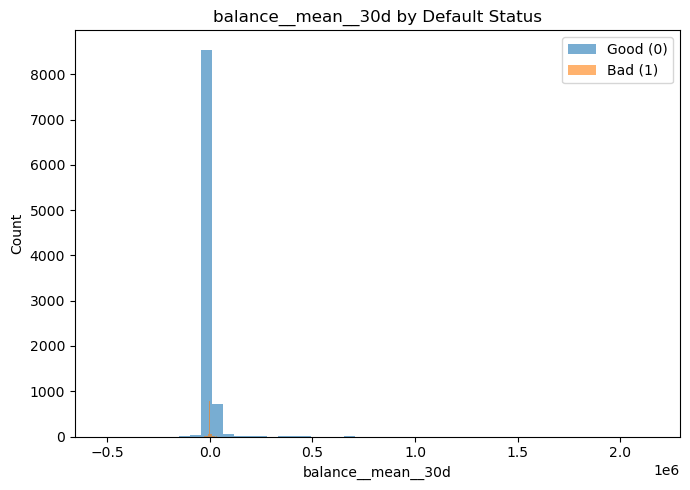

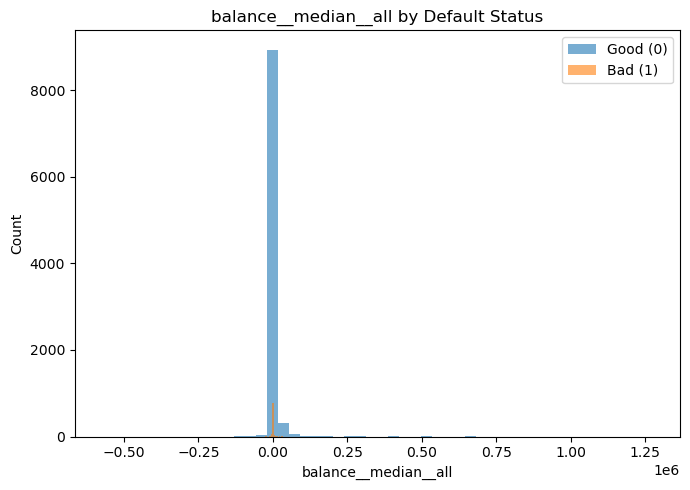

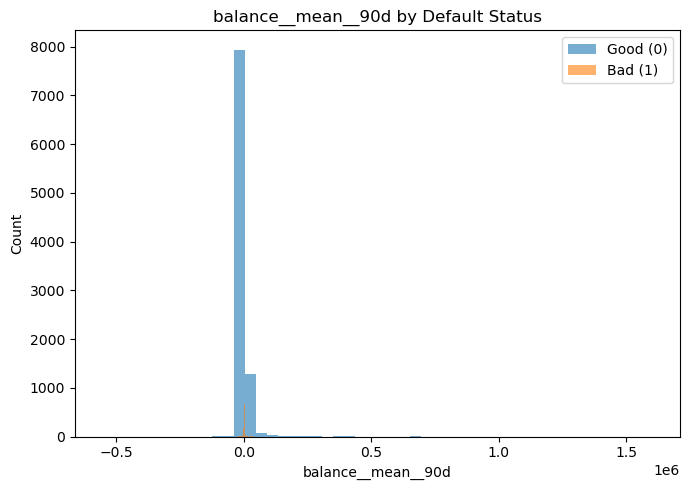

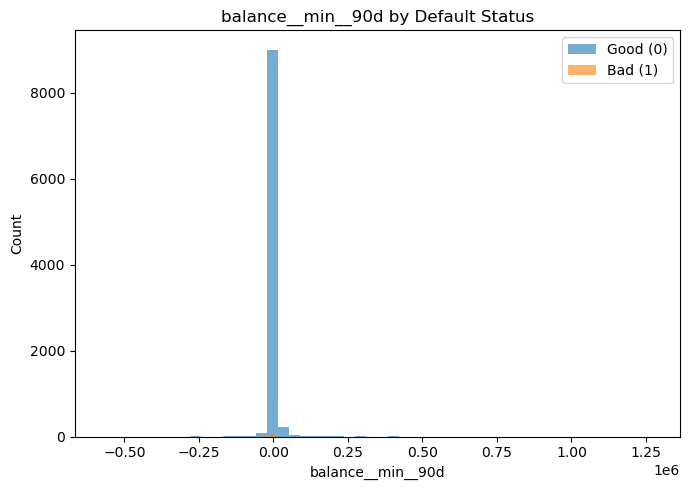

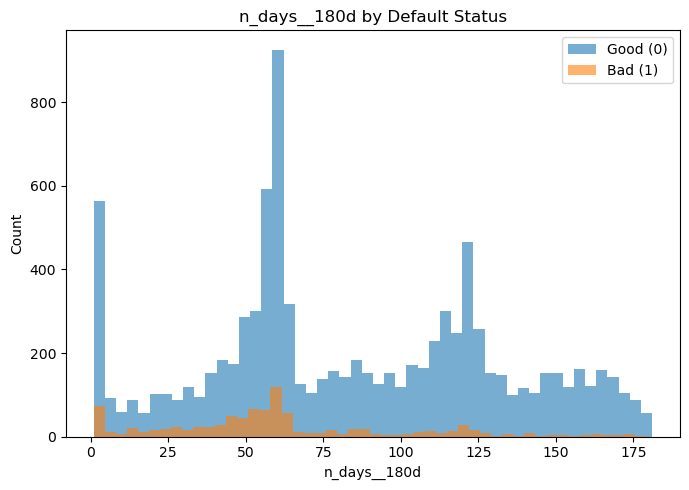

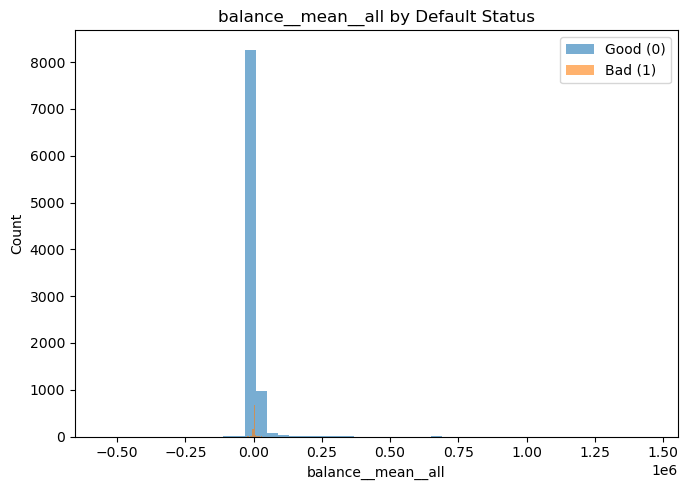

In [12]:
top_features = mi_scores.head(6).index.tolist()

def plot_feature(feature):
    plt.figure(figsize=(7,5))
    plt.hist(df[df["DQ_TARGET"]==0][feature], bins=50, alpha=0.6, label="Good (0)")
    plt.hist(df[df["DQ_TARGET"]==1][feature], bins=50, alpha=0.6, label="Bad (1)")
    plt.title(f"{feature} by Default Status")
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

for f in top_features:
    plot_feature(f)

In [13]:
pd.DataFrame([
    {
        "Feature": f,
        "Median_Good": df[df["DQ_TARGET"]==0][f].median(),
        "Median_Bad": df[df["DQ_TARGET"]==1][f].median()
    }
    for f in top_features
])

,Feature,Median_Good,Median_Bad
0,balance__mean__30d,980.909524,207.770642
1,balance__median__all,774.935000,101.880000
2,balance__mean__90d,984.482500,243.920000
3,balance__min__90d,37.040000,-79.285000
4,n_days__180d,78.000000,56.000000
5,balance__mean__all,998.950078,252.024174
